# Models Comparison

This notebook loads the trained RNN, LSTM, and GRU models and compares them using the functions in `src/evaluate.py`.

It expects each model's training notebook to have already saved:
- the trained model (as .keras or .h5)
- the training history (as a pickle)

Adjust the load paths below to match how you saved them in notebooks 03, 04, and 05.

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

import pickle
from keras.models import load_model
from src.evaluate import show_all_history_plots, evaluate_and_predict, generate_comparison_plots

## Load the test data and scaler
Same ones saved from the preprocessing notebook.

In [2]:
with open('../data/processed/all_model_data.pkl', 'rb') as f:
    all_data = pickle.load(f)

X_test = all_data['X_test']
y_test = all_data['y_test']

with open('../data/processed/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

target_index = 3
num_features = X_test.shape[2]

## Load the trained models
Update the filenames if you saved them differently.

In [3]:
rnn_model = load_model('../models/trained_model_RNN.keras')
lstm_model = load_model('../models/trained_model_LSTM.keras')
gru_model = load_model('../models/trained_model_GRU.keras')

att_rnn_model = load_model('../models/trained_model_Attention_RNN.keras')
att_lstm_model = load_model('../models/trained_model_Attention_LSTM.keras')
att_gru_model = load_model('../models/trained_model_Attention_GRU.keras')

models = [rnn_model, lstm_model, gru_model] + [att_rnn_model, att_lstm_model, att_gru_model]

## Load the training histories
Saved as pickles from each model's training notebook.

In [4]:
with open('../models/RNN_history.pkl', 'rb') as f:
    rnn_history = pickle.load(f)

with open('../models/LSTM_history.pkl', 'rb') as f:
    lstm_history = pickle.load(f)

with open('../models/GRU_history.pkl', 'rb') as f:
    gru_history = pickle.load(f)

with open('../models/Attention_RNN_history.pkl', 'rb') as f:
    att_rnn_history = pickle.load(f)

with open('../models/Attention_LSTM_history.pkl', 'rb') as f:
    att_lstm_history = pickle.load(f)

with open('../models/Attention_GRU_history.pkl', 'rb') as f:
    att_gru_history = pickle.load(f)

all_history = {
    'RNN': rnn_history,
    'LSTM': lstm_history,
    'GRU': gru_history,
    'Attention_RNN': att_rnn_history,
    'Attention_LSTM': att_lstm_history,
    'Attention_GRU': att_gru_history
}

## Loss and MSE curves for all models

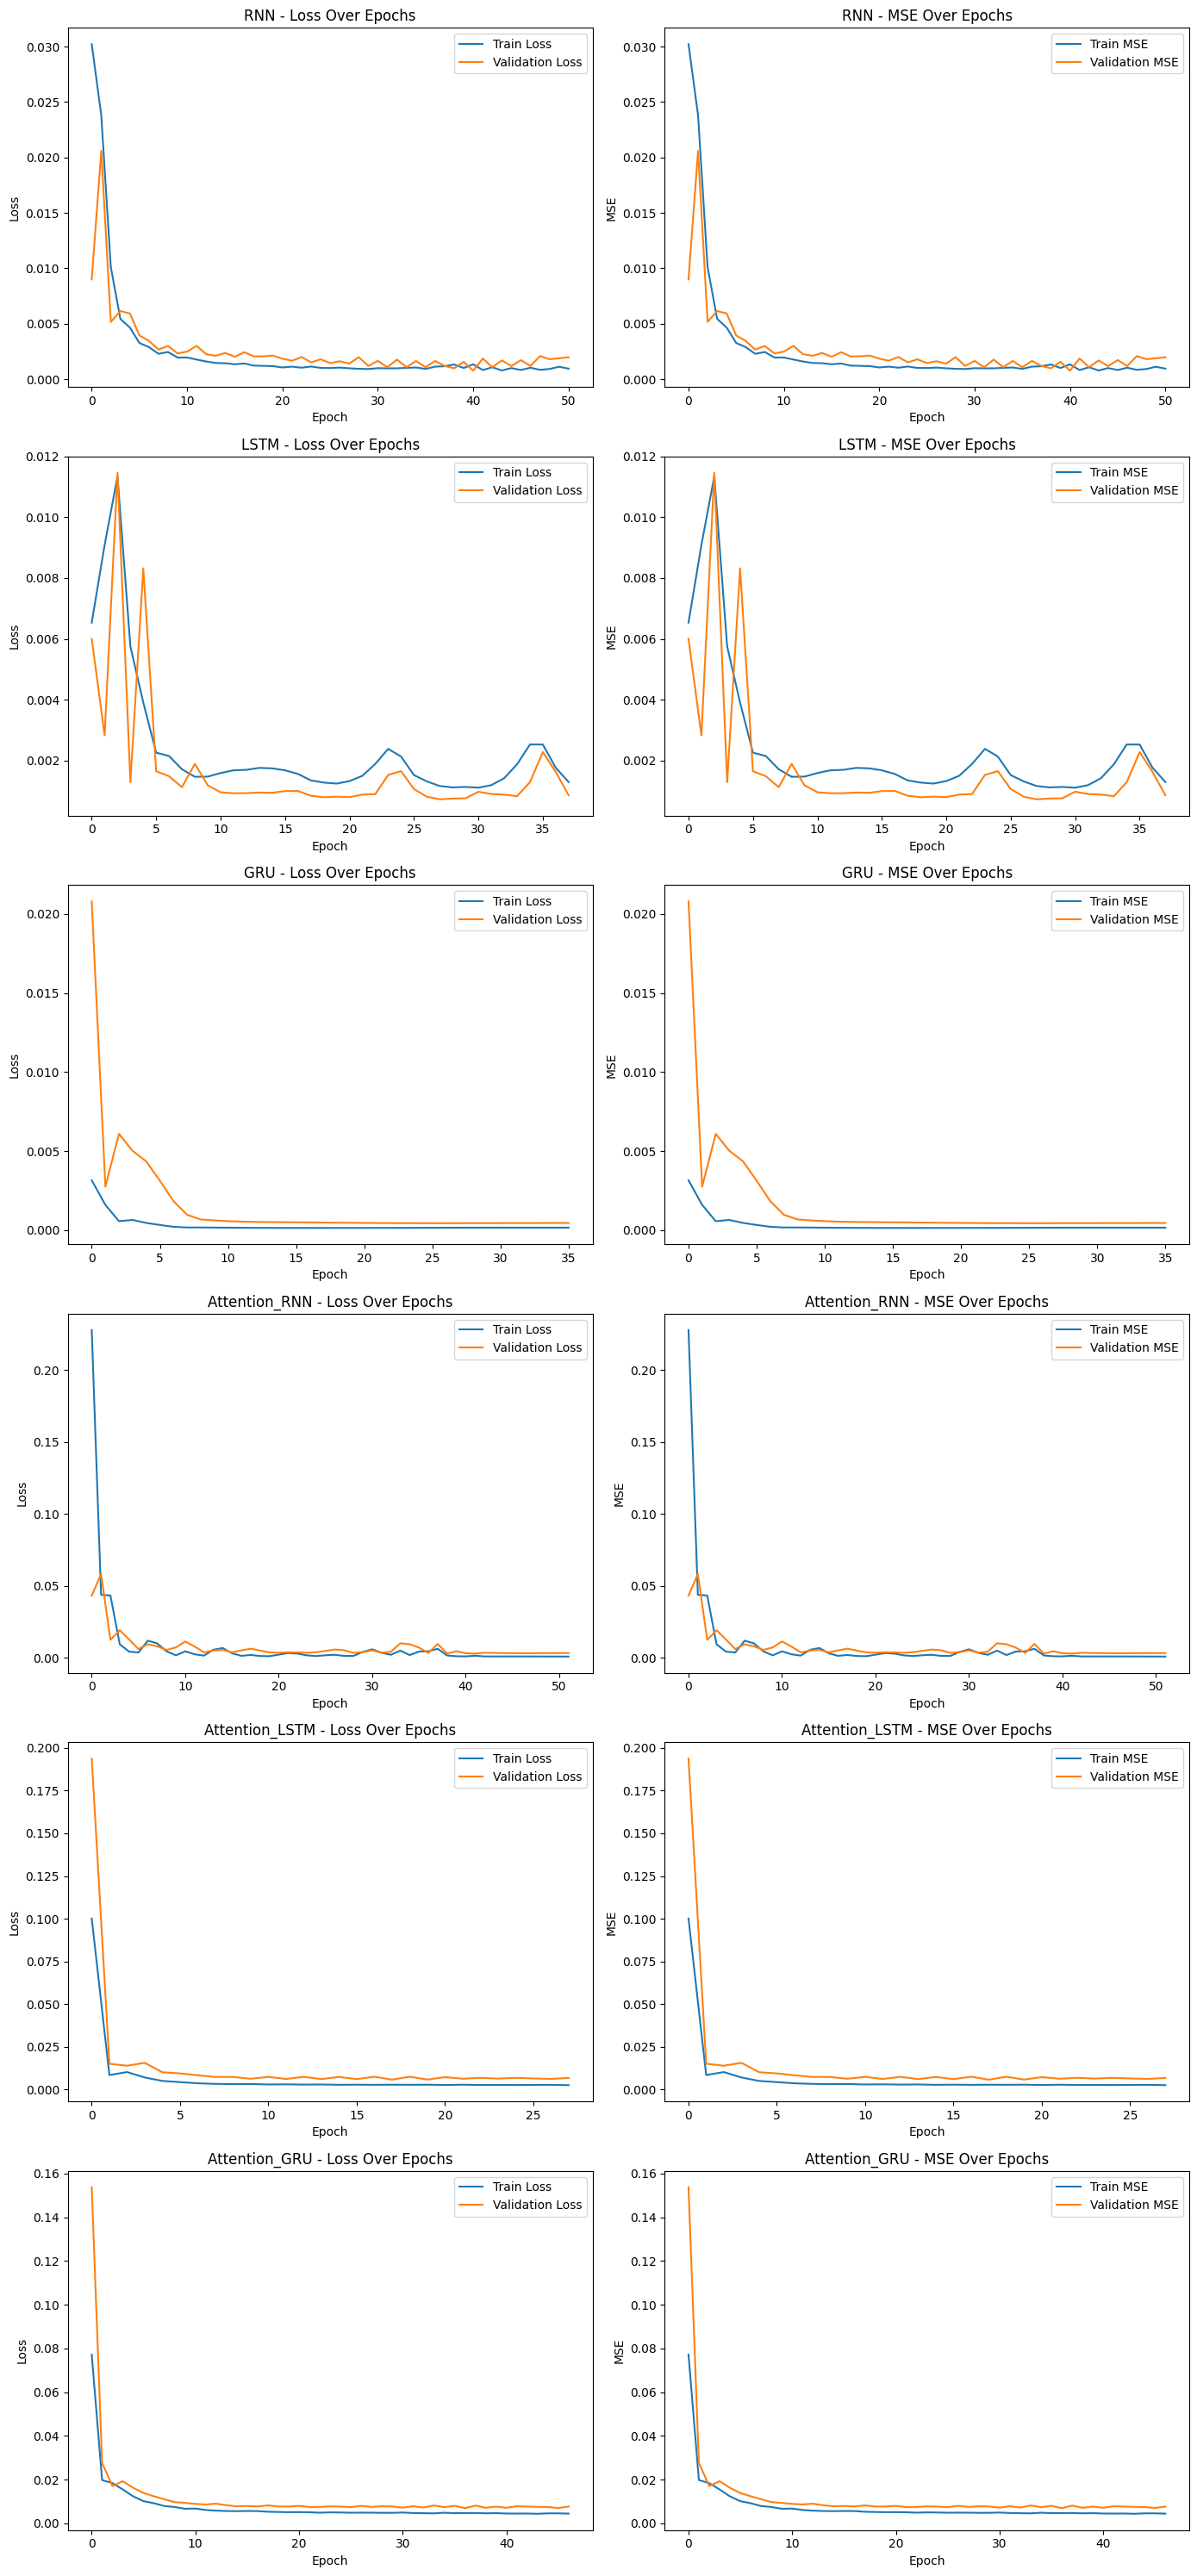

In [5]:
show_all_history_plots(all_history, save_dir='../results/plots')

## Evaluate on the test set
Prints the metrics for each model, plots predicted vs true prices, and saves everything to `results/`.

RNN - loss: 0.0131, mse: 0.0131, rmse: 22.5163, mae: 20.7303, mape: 7.98%


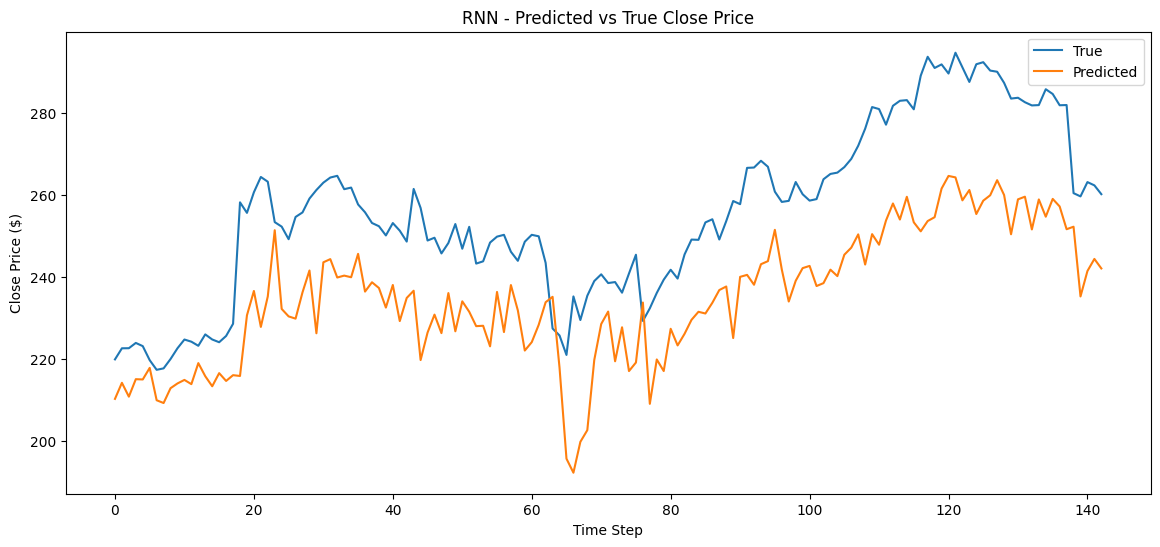

LSTM - loss: 0.0054, mse: 0.0054, rmse: 14.3841, mae: 11.8781, mape: 4.56%


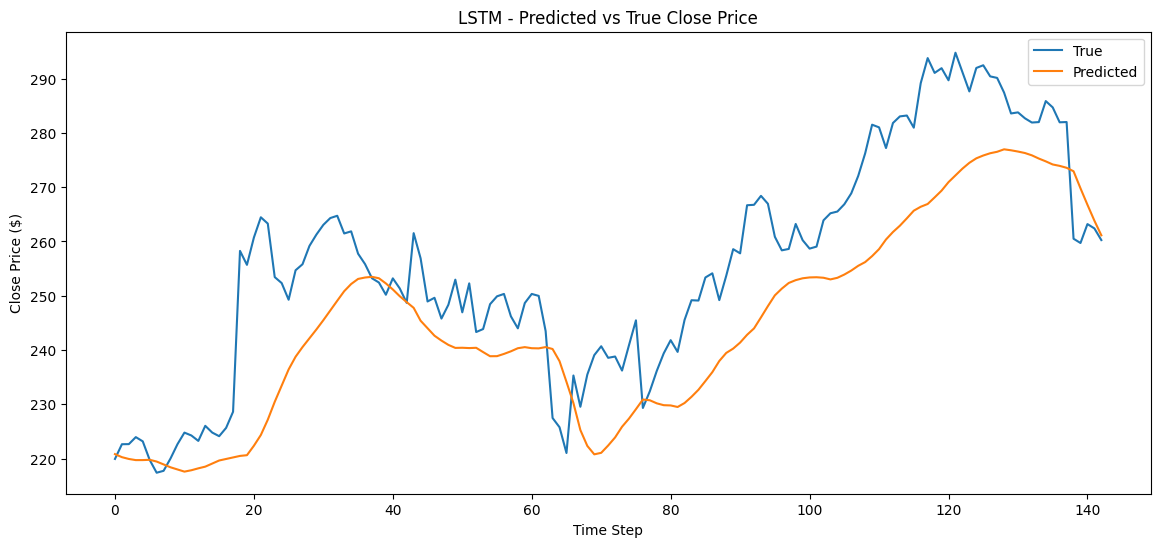

GRU - loss: 0.0062, mse: 0.0062, rmse: 15.4676, mae: 14.3012, mape: 5.51%


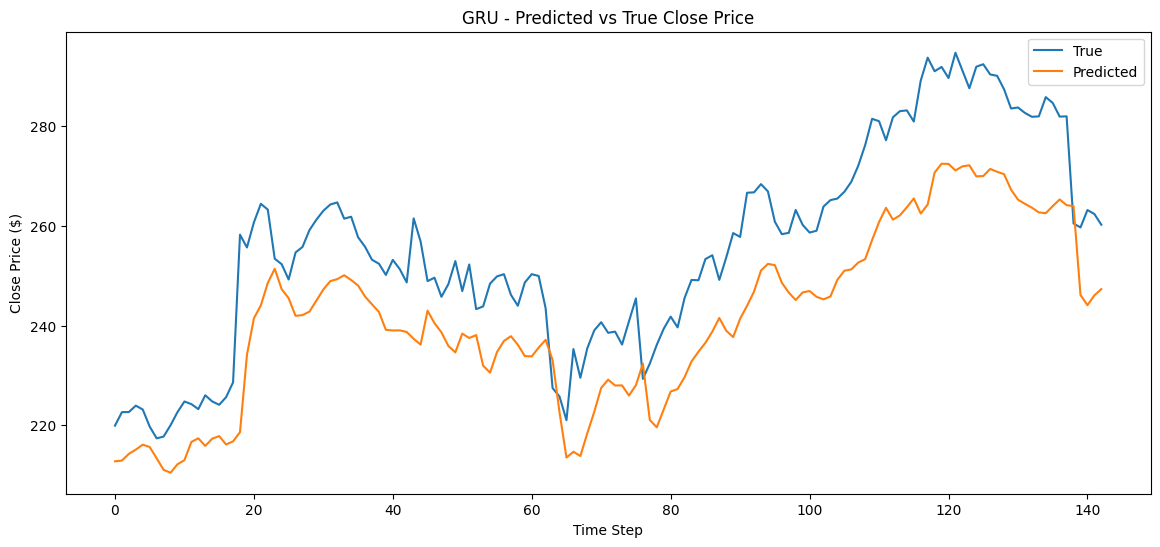

Attention_RNN - loss: 0.0071, mse: 0.0071, rmse: 16.5145, mae: 13.2247, mape: 4.99%


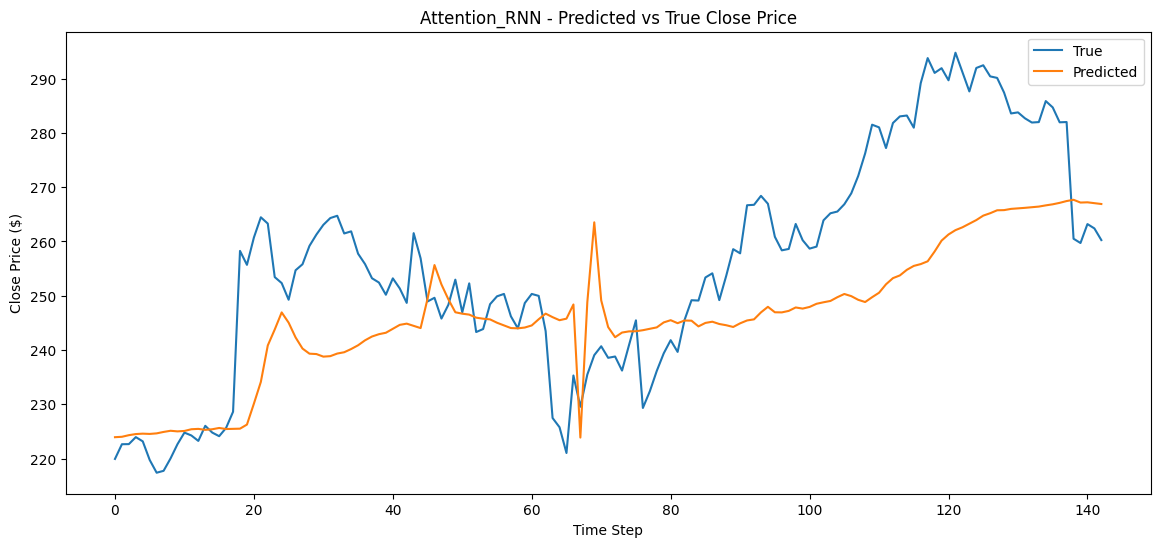

Attention_LSTM - loss: 0.0277, mse: 0.0277, rmse: 32.6875, mae: 28.5101, mape: 10.77%


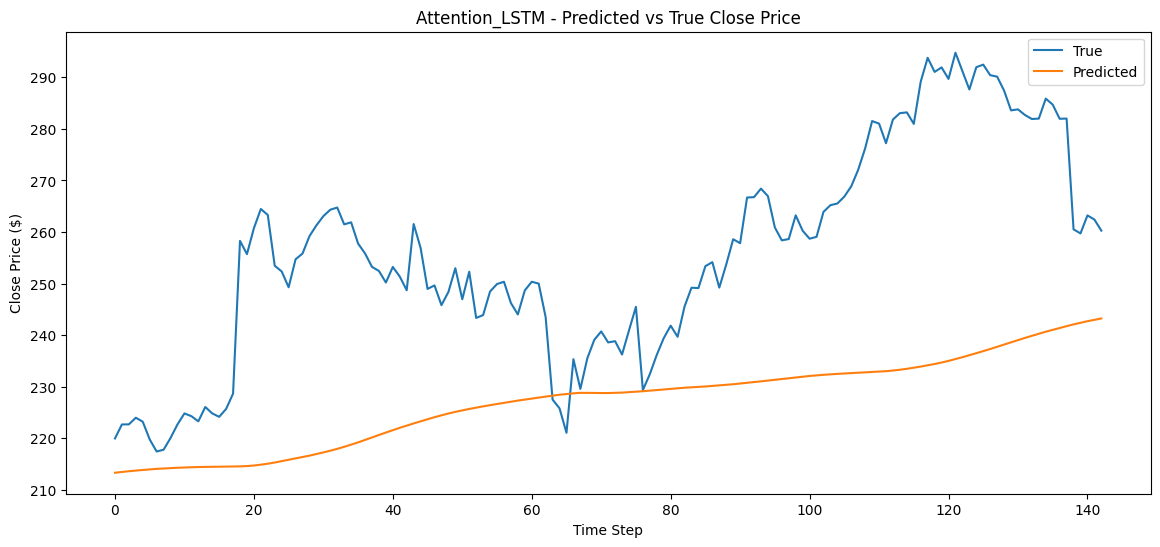

Attention_GRU - loss: 0.0185, mse: 0.0185, rmse: 26.7242, mae: 22.9642, mape: 8.69%


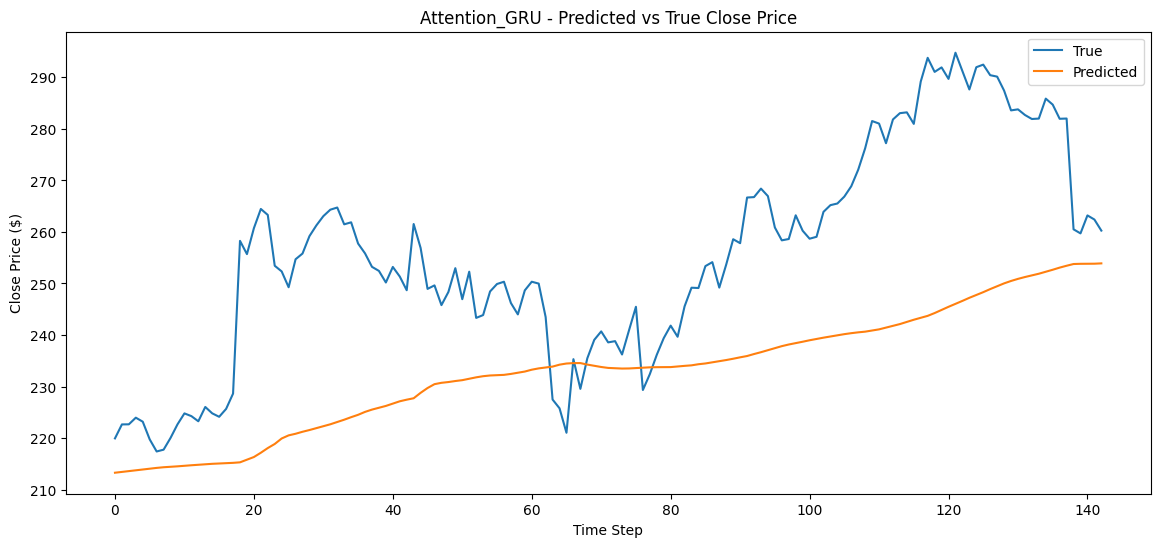

Metrics saved successfully


In [6]:
metrics_df, results = evaluate_and_predict(models, X_test, y_test, scaler, target_index, num_features, models_names=list(all_history.keys()), save_dir='../results')

## Metrics table

In [7]:
metrics_df

,Model,MSE,RMSE,MAE,MAPE
0,RNN,0.013129,22.516264,20.730344,7.975065
1,LSTM,0.005358,14.384119,11.878077,4.559365
2,GRU,0.006196,15.467646,14.301234,5.509344
3,Attention_RNN,0.007063,16.514490,13.224672,4.986174
4,Attention_LSTM,0.027669,32.687535,28.510104,10.765773
5,Attention_GRU,0.018494,26.724214,22.964157,8.686815


## Metrics comparison bar charts

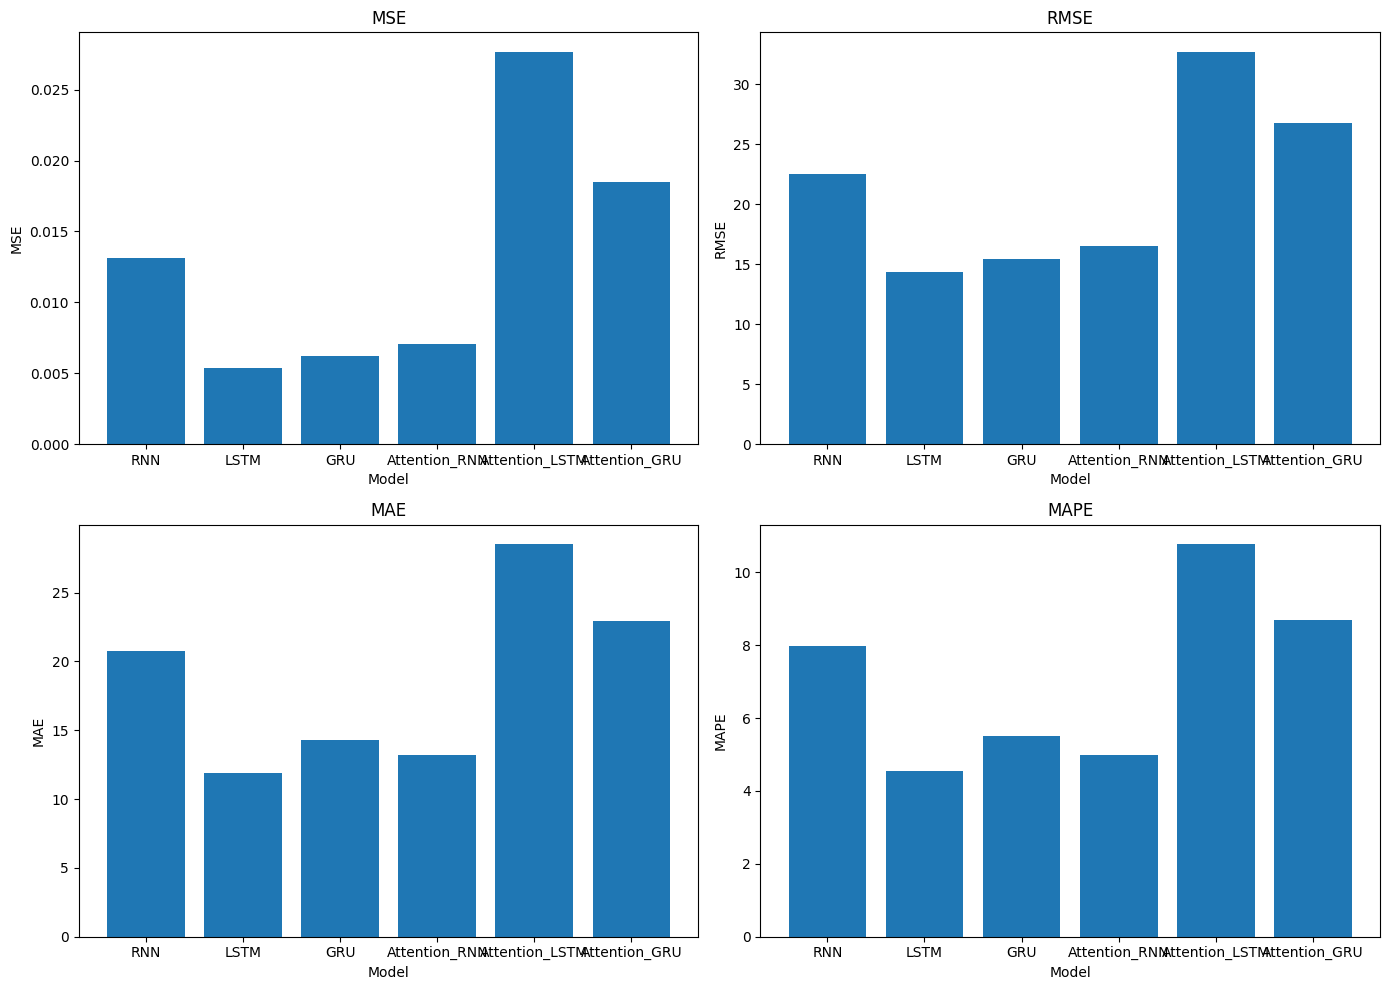

In [8]:
generate_comparison_plots(metrics_df, save_dir='../results/plots')